#  **Source Analysis of Final Coding**

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_DIR = os.path.abspath(".")
PROJECT_DIR = os.path.dirname(ANALYSIS_DIR)
DATA_DIR = os.path.join(PROJECT_DIR,"data")
TYPOLOGY_DIR = os.path.join(PROJECT_DIR,"typology_coding")
POLITICIAN_NAME = "Xi Jinping" #can be changed ofc
SAFE_NAME = POLITICIAN_NAME. replace(" ", "_")
POLITICIAN_DIR = os.path.join (DATA_DIR, SAFE_NAME)

CSV = os.path.join(TYPOLOGY_DIR, "Xi_Jinping_Definitive.csv")           

df = pd.read_csv(CSV)

### Basic info on Xi_Jinping_Merged.csv coding

In [13]:
df.head(3)

,Unnamed: 0.1,Unnamed: 0,index,uuid,title,description,snippet,url,source,language,...,S_codings,Z_codings,E_topic_coding,E_favorability_coding,S_topic_coding,S_favorability_coding,Z_topic_coding,Z_favorability_coding,Definitive_Topic,Definitive_Fav
0,0,0,1,e919651d-b28b-4e12-8fe1-3a120fdc0ed1,Biden confirms plans to talk to China’s Xi Jin...,"In addition, the US President stated his inten...","WASHINGTON, March 14. /TASS/. US President Joe...",https://tass.com/world/1588085,tass.com,en,...,"Diplomatic relations,Neutral","Diplomatic relations,Positive",Diplomatic relations,Positive,Diplomatic relations,Neutral,Diplomatic relations,Positive,Diplomatic relations,Positive
1,1,1,2,014d6ea3-df29-4b9f-8863-4cd74168e81c,Xi Jinping invites Trump to visit China,"According to the media report, the US presiden...","BEIJING, June 5. /TASS/. Chinese President Xi ...",https://tass.com/world/1969341,tass.com,en,...,"Domestic social policy,Positive","Diplomatic relations,Positive",Diplomatic relations,Positive,Domestic social policy,Positive,Diplomatic relations,Positive,Diplomatic relations,Positive
2,2,2,3,7464a488-c5cf-4bf1-9ce1-4f1f794cb0f8,Moments of Xi Jinping and non-CPC members,NaN,"Lin Shangyuan, a member of the Revolutionary C...",http://www.ecns.cn/video/2022-09-18/detail-ihc...,ecns.cn,en,...,"Military policy,Neutral","Domestic social policy,Positive",Domestic social policy,Positive,Military policy,Neutral,Domestic social policy,Positive,Domestic social policy,Positive


In [14]:
columns = list(df.head(0))  # Columns in a list
num_articles = df["uuid"].nunique() # Number of articles
sources = df["source"].unique() # Unique sources

print(f"Headers:\t{list(columns)}")
print(f"Num articles:\t{num_articles}")
print(f"Sources:\t{len(sources)}")

Headers:	['Unnamed: 0.1', 'Unnamed: 0', 'index', 'uuid', 'title', 'description', 'snippet', 'url', 'source', 'language', 'published_at', 'categories', 'E_codings', 'S_codings', 'Z_codings', 'E_topic_coding', 'E_favorability_coding', 'S_topic_coding', 'S_favorability_coding', 'Z_topic_coding', 'Z_favorability_coding', 'Definitive_Topic', 'Definitive_Fav']
Num articles:	502
Sources:	78


***Spliting articles by North American sources vs Non-NA sources***

In [15]:
na_sites = {
    "news.google.com",
    "reuters.com",
    "washingtonpost.com",
    "cnn.com",
    "thestar.com",
    "nationalpost.com",
    "globalnews.ca",
    "theglobeandmail.com",
    "nypost.com",
    "nytimes.com",
    "nbcnews.com",
    "cbc.ca",
    "cbsnews.com",
    "foxnews.com",
    "usatoday.com",
    "salon.com",
    "theatlantic.com",
    "abcnews.go.com",
    "vox.com",
    "cnbc.com",
    "jamestown.org",
    "today.com",
    "chinadigitaltimes.net",
    "breitbart.com"
}

europe_sites ={ 
    "dailymail.co.uk",
    "bbc.co.uk",
    "channel4.com",
    "france24.com",
    "news.sky.com",
    "ft.com",
    "theregister.com",
    "today.rtl.lu" # Rtl.lu is the official website for RTL Luxembourg !
    

}

canadian_sites = {
    
}

# All unique sources from df
all_sources = set(df["source"].unique())

# Split into North American and other sources
used_NA_sources = sorted(all_sources.intersection(na_sites))
used_other_sources = sorted(all_sources.difference(na_sites))

# Other useful groups
non_western_sources = sorted(all_sources.difference(na_sites).difference(europe_sites))
western_sorces = sorted(all_sources.difference(non_western_sources))
europe_sources = sorted(all_sources.difference(na_sites).difference(non_western_sources))

print(f"Western aritcles:\t\t{df["source"].isin(western_sorces).sum()} \
      \nNon western articles:\t\t{df["source"].isin(non_western_sources).sum()} \
      \nEuropean artices:\t\t{df["source"].isin(europe_sources).sum()}\n \
      Total articles:\t\t{len(df)}")
print(" - - - - - - - - - - - - - - - - - -")
print(f"Number of North American sourced articles:\t{df["source"].isin(na_sites).sum()} \
      \nNumber of Other sourced articles:\t\t{df["source"].isin(used_other_sources).sum()}\n \
      Total articles:\t\t{len(df)}")

Western aritcles:		296       
Non western articles:		206       
European artices:		8
       Total articles:		502
 - - - - - - - - - - - - - - - - - -
Number of North American sourced articles:	288       
Number of Other sourced articles:		214
       Total articles:		502


### Quick Source Analysis

### Topic Analysis

***Checking some of the most common sources***

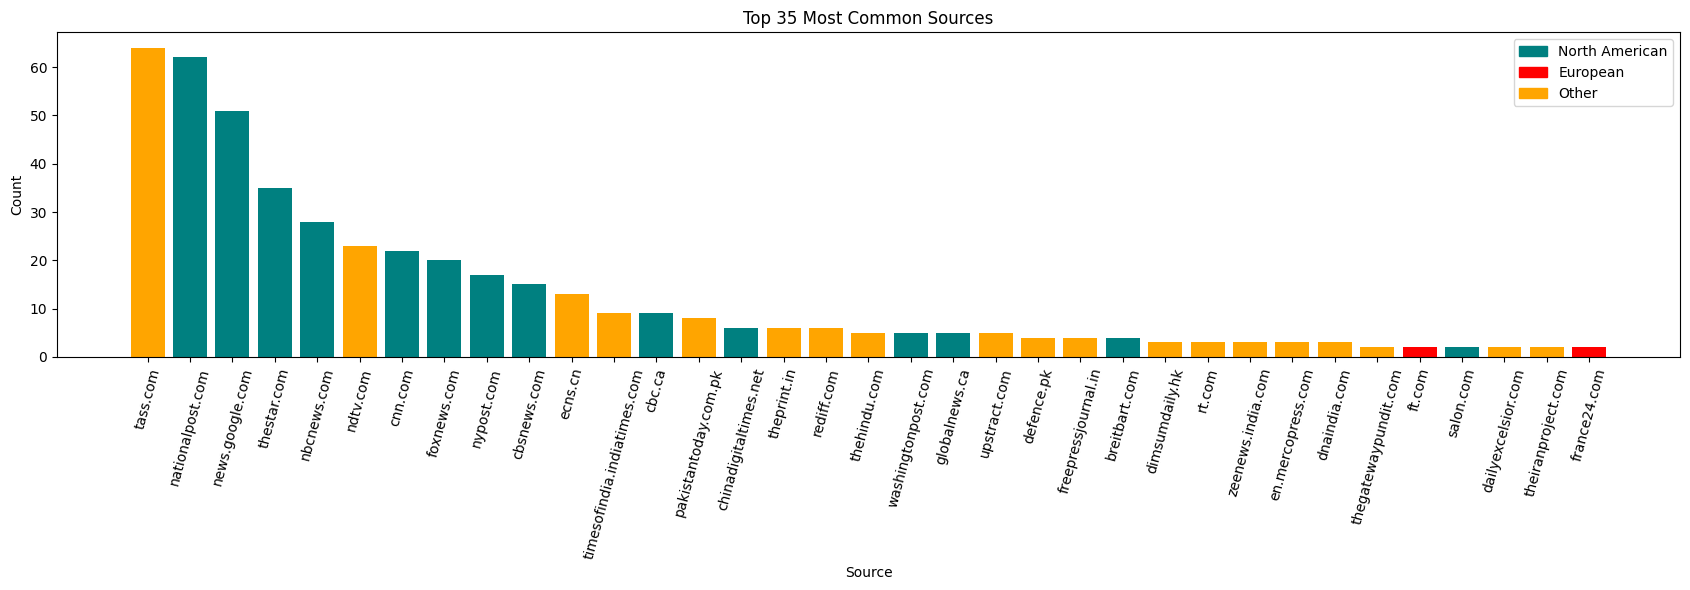

In [16]:
# Count the most common sources (top 20)
import matplotlib.patches as mpatches
counts = df["source"].value_counts().head(35)

#colors = ["teal" if src in na_sources else "orange" for src in counts.index]
# Color logic
colors = []
for src in counts.index:
    if src in na_sites:
        colors.append("teal")
    elif src in europe_sites:
        colors.append("red")
    else:
        colors.append("orange")

# Plot
plt.figure(figsize=(17, 6))
plt.bar(counts.index, counts.values, color=colors)
plt.xlabel("Source")
plt.ylabel("Count")
plt.title("Top 35 Most Common Sources")
plt.xticks(rotation=75)
plt.tight_layout()
# Legend
na_patch = mpatches.Patch(color='teal', label='North American')
uk_france_patch = mpatches.Patch(color='red', label='European')
other_patch = mpatches.Patch(color='orange', label='Other')
plt.legend(handles=[na_patch,uk_france_patch, other_patch])

#Save to images folder 
plt.savefig("../images/top_35_most_common_sources.png", dpi=300, bbox_inches='tight')

plt.show()

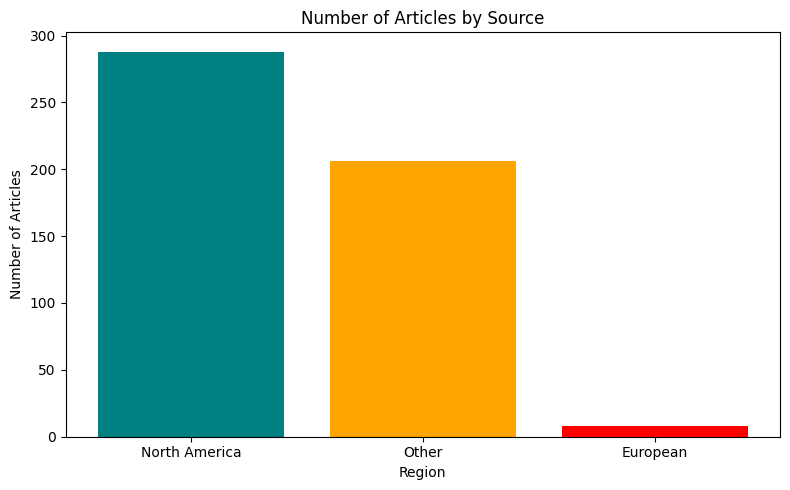

In [17]:
# Categorize each row in the df
def categorize_source(src):
    if src in na_sites:
        return "North America"
    elif src in europe_sites:
        return "European"
    else:
        return "Other"

df["category"] = df["source"].apply(categorize_source)

# Count categories
category_counts = df["category"].value_counts()

# Plot
plt.figure(figsize=(8, 5))
plt.bar(category_counts.index, category_counts.values, 
        color=["teal", "orange", "red"])
plt.xlabel("Region")
plt.ylabel("Number of Articles")
plt.title("Number of Articles by Source")
plt.tight_layout()

#Save plot
plt.savefig("../images/num_articles_by_source_type.png", dpi=300, bbox_inches='tight')
plt.show()